# STAGE 8 — THRESHOLD OPTIMIZATION

## 1. Objective

Stage 8 investigates whether changing the binary classification decision threshold can improve minority-class performance on the Bank Marketing classification problem.

The default classification threshold is 0.50.

Instead of assuming that 0.50 is optimal, thresholds from 0.10 to 0.90 were evaluated.

The threshold was selected using out-of-fold predictions generated from the training data.

---

## 2. Dataset

The experiment uses the UCI Bank Marketing `bank-full.csv` dataset.

The target variable is:

`y`

Encoding:

- `no` → 0
- `yes` → 1

The dataset is imbalanced, with approximately 88.3% negative observations and 11.7% positive observations.

---

## 3. Model

Logistic Regression was used for the primary threshold optimization experiment.

The model was placed inside a preprocessing pipeline containing:

- StandardScaler for numerical variables
- OneHotEncoder for categorical variables

---

## 4. Out-of-fold threshold selection

Threshold selection was performed using out-of-fold predictions from three-fold stratified cross-validation on the training data.

For every fold:

1. The model was trained on the fold training data.
2. Predictions were generated for the validation fold.
3. Positive-class probabilities were stored.
4. The process was repeated for all folds.

The resulting out-of-fold probabilities provide predictions for every training observation from a model that did not train on that observation.

These probabilities were used to evaluate thresholds.

---

## 5. Threshold search

Thresholds between 0.10 and 0.90 were evaluated in increments of 0.01.

For each threshold the following metrics were calculated:

- Accuracy
- Precision
- Recall
- F1-score
- Balanced Accuracy

The threshold that maximized F1-score on the training out-of-fold predictions was selected for the primary threshold-optimized evaluation.

A separate Balanced Accuracy optimum was also calculated for comparison.

---

## 6. Why F1-score?

F1-score combines Precision and Recall.

Because the positive class is the minority class, F1-score provides a more informative objective than accuracy alone.

The threshold was therefore selected based on F1 rather than overall accuracy.

---

## 7. Precision-Recall trade-off

Changing the threshold changes the balance between Precision and Recall.

A lower threshold generally makes the classifier more likely to predict the positive class.

This can increase Recall while potentially reducing Precision.

A higher threshold generally makes the classifier more conservative when predicting the positive class.

This can increase Precision while potentially reducing Recall.

Stage 8 visualizes this trade-off.

---

## 8. Threshold-independent metrics

PR-AUC and ROC-AUC were also calculated using the predicted probabilities.

These metrics are not dependent on a single classification threshold.

Therefore, changing the threshold changes the final class predictions but does not change the underlying probability ranking used to calculate PR-AUC and ROC-AUC.

---

## 9. Test-set evaluation

After selecting the threshold using training out-of-fold predictions:

1. The final Logistic Regression model was trained on all training data.
2. Probabilities were generated for the untouched test data.
3. Test predictions were generated using:
   - threshold 0.50
   - F1-optimized threshold
4. The two approaches were compared.

The test set was not used to select the threshold.

---

## 10. Research question

The main research question is:

> Does threshold optimization improve minority-class classification performance compared with the conventional 0.50 classification threshold?

The answer is determined empirically from the experiment rather than assumed in advance.

---

## 11. Relationship with previous stages

Stage 5:

Imbalance handling

- Class weighting
- SMOTENC

Stage 6:

Single-objective HPO

- F1 optimization

Stage 7:

Multi-objective HPO

- F1
- PR-AUC

Stage 8:

Threshold optimization

- Decision threshold selection

These are separate mechanisms.

HPO changes model hyperparameters.

Imbalance methods change how the model learns from the class distribution.

Threshold optimization changes the conversion of predicted probabilities into final class labels.

---

## 12. Important limitation

A threshold that maximizes F1 is not automatically the correct threshold for every real-world application.

Different applications may have different costs associated with:

- False Positives
- False Negatives

Therefore, threshold selection should ultimately reflect the intended operational objective.

The current experiment uses F1-score as the primary threshold-selection criterion because the research focuses on imbalanced classification performance.

---

## 13. Outputs

Stage 8 generates:

`results/metrics/threshold_optimization_results.csv`

Contains performance across the evaluated thresholds.

`results/metrics/threshold_test_comparison.csv`

Contains the comparison between the default and optimized threshold on the untouched test set.

`results/metrics/selected_threshold.csv`

Contains the selected threshold and its training cross-validation performance.

---

## 14. Research significance

Threshold optimization adds another decision layer to the proposed research framework.

The study does not only ask:

> Which model is best?

It also investigates:

> How does the decision threshold affect minority-class performance?

This helps separate model learning performance from the final classification decision rule.

The findings from Stage 8 will later be combined with:

- HPO results
- imbalance-strategy results
- robustness analysis
- SHAP explainability
- explanation stability

to produce the final research conclusions.

In [1]:
import os
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
data_path = "../data/raw/bank-full.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,18,student,single,primary,no,1944,no,no,telephone,10,aug,122,3,-1,0,unknown,no
1,18,student,single,unknown,no,108,no,no,cellular,10,aug,167,1,-1,0,unknown,yes
2,18,student,single,primary,no,608,no,no,cellular,12,aug,267,1,-1,0,unknown,yes
3,18,student,single,unknown,no,35,no,no,telephone,21,aug,104,2,-1,0,unknown,no
4,18,student,single,secondary,no,5,no,no,cellular,24,aug,143,2,-1,0,unknown,no


In [3]:
X = df.drop(columns=["y"]).copy()

y = df["y"].map({
    "no": 0,
    "yes": 1
})

if y.isna().any():
    raise ValueError(
        "Target encoding produced missing values."
    )

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print(
    (y.value_counts(normalize=True) * 100).round(2)
)

Features shape: (45211, 16)
Target shape: (45211,)

Target distribution:
y
0    39922
1     5289
Name: count, dtype: int64

Target percentage:
y
0    88.3
1    11.7
Name: proportion, dtype: float64


In [4]:
numerical_columns = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = X.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical features:")
print(numerical_columns)

print("\nCategorical features:")
print(categorical_columns)

print("\nNumerical feature count:",
      len(numerical_columns))

print("Categorical feature count:",
      len(categorical_columns))

Numerical features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numerical feature count: 7
Categorical feature count: 9


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts())

print("\nTesting target:")
print(y_test.value_counts())

X_train: (36168, 16)
X_test: (9043, 16)

Training target:
y
0    31937
1     4231
Name: count, dtype: int64

Testing target:
y
0    7985
1    1058
Name: count, dtype: int64


In [7]:
numerical_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_transformer,
            numerical_columns
        ),
        (
            "cat",
            categorical_transformer,
            categorical_columns
        )
    ],
    remainder="drop"
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [8]:
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

print("Cross-validation configured.")
print("Number of folds:", cv.n_splits)
print("Random state:", cv.random_state)

Cross-validation configured.
Number of folds: 3
Random state: 42


# Stage 8 — Classification Threshold Optimization

## 1. Purpose

A binary classification model produces a probability for the positive class.

For example:

P(y = 1) = 0.37

A default classification threshold of 0.50 would classify this observation as:

0.37 < 0.50 → class 0

However, the threshold does not have to be fixed at 0.50.

Stage 8 investigates whether changing the threshold can improve minority-class classification performance.

---

## 2. Why threshold optimization matters for imbalanced classification

Our Bank Marketing dataset contains approximately:

- 88.3% negative observations
- 11.7% positive observations

The positive class is therefore the minority class.

A threshold of 0.50 may produce a decision rule that does not provide the desired balance between Precision and Recall.

Lowering the threshold generally makes the classifier more willing to predict the positive class.

This can increase Recall but may also increase False Positives.

Increasing the threshold generally makes the classifier more conservative when predicting the positive class.

This can increase Precision but may reduce Recall.

Therefore, threshold selection is a trade-off.

---

## 3. Important distinction

Threshold optimization does NOT retrain the model.

The trained model still produces probabilities.

Only the rule used to convert probabilities into class labels changes.

Example:

Probability = 0.37

Threshold 0.50:

0.37 < 0.50 → NO

Threshold 0.30:

0.37 >= 0.30 → YES

Therefore:

Model training → probability

Threshold → final class prediction

---

## 4. Why should the test set not be used for threshold selection?

The test set must remain an unbiased evaluation dataset.

If the threshold is selected using the test set and the final performance is then reported on the same test set, the test data influences the model decision process.

This introduces a form of evaluation leakage.

Therefore:

Training data
↓
Cross-validation
↓
Threshold selection
↓
Train final model
↓
Untouched test data
↓
Final evaluation

---

## 5. Metrics

The following metrics are evaluated:

### Accuracy

Overall proportion of correctly classified observations.

Accuracy is not the primary optimization metric because of class imbalance.

### Precision

Among predicted positive customers, the proportion that are actually positive.

### Recall

Among actual positive customers, the proportion successfully identified.

### F1-score

Harmonic mean of Precision and Recall.

### Balanced Accuracy

Average of the recall obtained on each class.

This gives more balanced treatment to the majority and minority classes.

### PR-AUC

Measures precision-recall performance across thresholds.

It is useful for imbalanced classification.

### ROC-AUC

Measures ranking/discrimination ability across thresholds.

---

## 6. Research objective

Stage 8 investigates:

> Whether selecting a decision threshold based on cross-validation improves minority-class performance compared with the conventional 0.50 threshold.

The experiment will also show the Precision-Recall trade-off produced by different thresholds.

---

## 7. Relationship with previous stages

Stage 5 investigated explicit imbalance strategies:

- Class weighting
- SMOTENC

Stage 6 investigated:

- Single-objective HPO

Stage 7 investigated:

- Multi-objective HPO

Stage 8 investigates:

- Decision threshold optimization

These are different mechanisms.

HPO changes model hyperparameters.

Imbalance handling changes how the model learns from class distributions.

Threshold optimization changes how model probabilities are converted into final predictions.

---

## 8. Important interpretation

Threshold optimization does not prove that one threshold is universally best.

The appropriate threshold depends on the desired balance between false positives and false negatives.

Therefore, Stage 8 reports the threshold-performance relationship rather than assuming that 0.50 is always optimal.

In [9]:
def calculate_threshold_metrics(
    y_true,
    y_probability,
    threshold
):
    
    y_prediction = (
        y_probability >= threshold
    ).astype(int)

    return {
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_true,
            y_prediction
        ),
        "Precision": precision_score(
            y_true,
            y_prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            y_prediction,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            y_prediction,
            zero_division=0
        ),
        "Balanced_Accuracy": balanced_accuracy_score(
            y_true,
            y_prediction
        )
    }


print("Threshold evaluation function created.")

Threshold evaluation function created.


In [10]:
thresholds = np.round(
    np.arange(0.10, 0.91, 0.01),
    2
)

print("Number of thresholds:",
      len(thresholds))

print("\nFirst thresholds:")
print(thresholds[:10])

print("\nLast thresholds:")
print(thresholds[-10:])

Number of thresholds: 81

First thresholds:
[0.1  0.11 0.12 0.13 0.14 0.15 0.16 0.17 0.18 0.19]

Last thresholds:
[0.81 0.82 0.83 0.84 0.85 0.86 0.87 0.88 0.89 0.9 ]


In [11]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

print("Logistic Regression model created.")

Logistic Regression model created.


In [12]:
oof_probabilities = np.zeros(
    len(y_train)
)

for train_idx, valid_idx in cv.split(
    X_train,
    y_train
):

    X_fold_train = X_train.iloc[train_idx]
    X_fold_valid = X_train.iloc[valid_idx]

    y_fold_train = y_train.iloc[train_idx]

    fold_model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "classifier",
                LogisticRegression(
                    max_iter=1000,
                    random_state=42
                )
            )
        ]
    )

    fold_model.fit(
        X_fold_train,
        y_fold_train
    )

    oof_probabilities[valid_idx] = (
        fold_model.predict_proba(
            X_fold_valid
        )[:, 1]
    )

print("Out-of-fold probabilities generated successfully.")

print("\nNumber of probabilities:",
      len(oof_probabilities))

print("Expected:",
      len(y_train))

Out-of-fold probabilities generated successfully.

Number of probabilities: 36168
Expected: 36168


In [13]:
assert len(oof_probabilities) == len(y_train)

assert np.isfinite(
    oof_probabilities
).all()

assert (
    oof_probabilities.min() >= 0
)

assert (
    oof_probabilities.max() <= 1
)

print("✓ OOF probability count is correct.")
print("✓ No invalid probability values found.")

print("\nProbability range:")
print(
    round(oof_probabilities.min(), 4),
    "to",
    round(oof_probabilities.max(), 4)
)

✓ OOF probability count is correct.
✓ No invalid probability values found.

Probability range:
0.0 to 1.0


In [14]:
threshold_results = []

for threshold in thresholds:

    result = calculate_threshold_metrics(
        y_train,
        oof_probabilities,
        threshold
    )

    threshold_results.append(result)

threshold_results_df = pd.DataFrame(
    threshold_results
)

print("Threshold evaluation completed.")

display(
    threshold_results_df.head(10)
)

Threshold evaluation completed.


,Threshold,Accuracy,Precision,Recall,F1,Balanced_Accuracy
0,0.10,0.815362,0.374397,0.861971,0.522044,0.835579
1,0.11,0.829297,0.392782,0.841172,0.535510,0.834448
2,0.12,0.840384,0.408951,0.818483,0.545397,0.830884
3,0.13,0.849038,0.422889,0.796502,0.552459,0.826250
4,0.14,0.856392,0.436047,0.775939,0.558333,0.821495
5,0.15,0.862862,0.448842,0.755850,0.563226,0.816444
6,0.16,0.867618,0.458978,0.736469,0.565517,0.810731
7,0.17,0.873037,0.472063,0.720870,0.570520,0.807033
8,0.18,0.877544,0.483949,0.705507,0.574094,0.802921
9,0.19,0.880640,0.492692,0.685181,0.573208,0.795858


In [15]:
best_f1_row = threshold_results_df.loc[
    threshold_results_df["F1"].idxmax()
]

best_f1_threshold = best_f1_row["Threshold"]

print("=" * 80)
print("F1-OPTIMAL THRESHOLD")
print("=" * 80)

print("\nThreshold:",
      best_f1_threshold)

print("F1:",
      round(best_f1_row["F1"], 4))

print("Precision:",
      round(best_f1_row["Precision"], 4))

print("Recall:",
      round(best_f1_row["Recall"], 4))

print("Balanced Accuracy:",
      round(
          best_f1_row["Balanced_Accuracy"],
          4
      ))

F1-OPTIMAL THRESHOLD

Threshold: 0.22
F1: 0.5763
Precision: 0.5216
Recall: 0.6438
Balanced Accuracy: 0.7828


In [16]:
best_balanced_row = threshold_results_df.loc[
    threshold_results_df["Balanced_Accuracy"].idxmax()
]

best_balanced_threshold = (
    best_balanced_row["Threshold"]
)

print("=" * 80)
print("BALANCED-ACCURACY-OPTIMAL THRESHOLD")
print("=" * 80)

print("\nThreshold:",
      best_balanced_threshold)

print("Balanced Accuracy:",
      round(
          best_balanced_row[
              "Balanced_Accuracy"
          ],
          4
      ))

print("F1:",
      round(best_balanced_row["F1"], 4))

print("Precision:",
      round(
          best_balanced_row["Precision"],
          4
      ))

print("Recall:",
      round(
          best_balanced_row["Recall"],
          4
      ))

BALANCED-ACCURACY-OPTIMAL THRESHOLD

Threshold: 0.1
Balanced Accuracy: 0.8356
F1: 0.522
Precision: 0.3744
Recall: 0.862


In [17]:
default_threshold_row = threshold_results_df.loc[
    threshold_results_df["Threshold"] == 0.50
].iloc[0]

comparison_thresholds = pd.DataFrame([
    {
        "Threshold Type": "Default",
        "Threshold": 0.50,
        "Precision": default_threshold_row["Precision"],
        "Recall": default_threshold_row["Recall"],
        "F1": default_threshold_row["F1"],
        "Balanced Accuracy": default_threshold_row["Balanced_Accuracy"]
    },
    {
        "Threshold Type": "F1 Optimized",
        "Threshold": best_f1_threshold,
        "Precision": best_f1_row["Precision"],
        "Recall": best_f1_row["Recall"],
        "F1": best_f1_row["F1"],
        "Balanced Accuracy": best_f1_row["Balanced_Accuracy"]
    },
    {
        "Threshold Type": "Balanced Accuracy Optimized",
        "Threshold": best_balanced_threshold,
        "Precision": best_balanced_row["Precision"],
        "Recall": best_balanced_row["Recall"],
        "F1": best_balanced_row["F1"],
        "Balanced Accuracy": best_balanced_row["Balanced_Accuracy"]
    }
])

display(
    comparison_thresholds.round(4)
)

,Threshold Type,Threshold,Precision,Recall,F1,Balanced Accuracy
0,Default,0.50,0.6491,0.3432,0.4490,0.6593
1,F1 Optimized,0.22,0.5216,0.6438,0.5763,0.7828
2,Balanced Accuracy Optimized,0.10,0.3744,0.8620,0.5220,0.8356


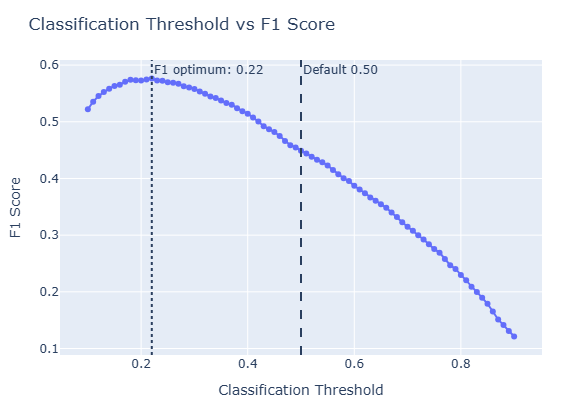

In [18]:
fig = px.line(
    threshold_results_df,
    x="Threshold",
    y="F1",
    markers=True,
    title="Classification Threshold vs F1 Score",
    labels={
        "Threshold": "Classification Threshold",
        "F1": "F1 Score"
    }
)

fig.add_vline(
    x=0.50,
    line_dash="dash",
    annotation_text="Default 0.50"
)

fig.add_vline(
    x=best_f1_threshold,
    line_dash="dot",
    annotation_text=f"F1 optimum: {best_f1_threshold:.2f}"
)

fig.update_layout(
    width=700,
    height=400,
    margin=dict(
        l=60,
        r=30,
        t=60,
        b=60
    )
)

fig.show()

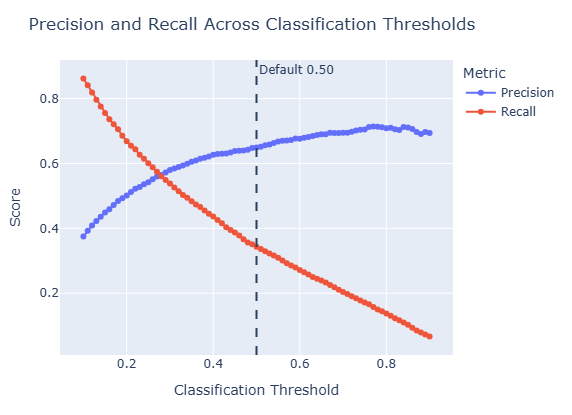

In [19]:
precision_recall_threshold = threshold_results_df[
    [
        "Threshold",
        "Precision",
        "Recall"
    ]
]

fig = px.line(
    precision_recall_threshold,
    x="Threshold",
    y=[
        "Precision",
        "Recall"
    ],
    markers=True,
    title="Precision and Recall Across Classification Thresholds",
    labels={
        "Threshold": "Classification Threshold",
        "value": "Score",
        "variable": "Metric"
    }
)

fig.add_vline(
    x=0.50,
    line_dash="dash",
    annotation_text="Default 0.50"
)

fig.update_layout(
    width=700,
    height=400,
    margin=dict(
        l=60,
        r=30,
        t=60,
        b=60
    )
)

fig.show()

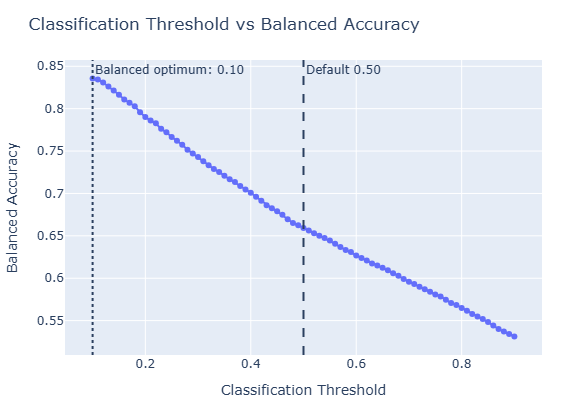

In [20]:
fig = px.line(
    threshold_results_df,
    x="Threshold",
    y="Balanced_Accuracy",
    markers=True,
    title="Classification Threshold vs Balanced Accuracy",
    labels={
        "Threshold": "Classification Threshold",
        "Balanced_Accuracy": "Balanced Accuracy"
    }
)

fig.add_vline(
    x=0.50,
    line_dash="dash",
    annotation_text="Default 0.50"
)

fig.add_vline(
    x=best_balanced_threshold,
    line_dash="dot",
    annotation_text=(
        f"Balanced optimum: "
        f"{best_balanced_threshold:.2f}"
    )
)

fig.update_layout(
    width=700,
    height=400,
    margin=dict(
        l=60,
        r=30,
        t=60,
        b=60
    )
)

fig.show()

In [21]:
oof_pr_auc = average_precision_score(
    y_train,
    oof_probabilities
)

oof_roc_auc = roc_auc_score(
    y_train,
    oof_probabilities
)

print("=" * 80)
print("THRESHOLD-INDEPENDENT METRICS")
print("=" * 80)

print("\nOOF PR-AUC:",
      round(oof_pr_auc, 4))

print("OOF ROC-AUC:",
      round(oof_roc_auc, 4))

THRESHOLD-INDEPENDENT METRICS

OOF PR-AUC: 0.5488
OOF ROC-AUC: 0.9046


In [22]:
final_logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

final_logistic_model.fit(
    X_train,
    y_train
)

print("Final Logistic Regression model trained.")

Final Logistic Regression model trained.


In [23]:
test_probabilities = (
    final_logistic_model
    .predict_proba(X_test)[:, 1]
)

print("Test probabilities generated.")

print("\nNumber of predictions:",
      len(test_probabilities))

print("Probability range:",
      round(test_probabilities.min(), 4),
      "to",
      round(test_probabilities.max(), 4))

Test probabilities generated.

Number of predictions: 9043
Probability range: 0.0001 to 1.0


In [24]:
test_prediction_default = (
    test_probabilities >= 0.50
).astype(int)

default_test_metrics = {
    "Threshold": 0.50,
    "Accuracy": accuracy_score(
        y_test,
        test_prediction_default
    ),
    "Precision": precision_score(
        y_test,
        test_prediction_default,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        test_prediction_default,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        test_prediction_default,
        zero_division=0
    ),
    "Balanced_Accuracy": balanced_accuracy_score(
        y_test,
        test_prediction_default
    ),
    "PR_AUC": average_precision_score(
        y_test,
        test_probabilities
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        test_probabilities
    )
}

default_test_metrics_df = pd.DataFrame([
    default_test_metrics
])

display(
    default_test_metrics_df.round(4)
)

,Threshold,Accuracy,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,ROC_AUC
0,0.5,0.9022,0.6543,0.3488,0.455,0.6622,0.5591,0.9109


In [26]:
test_prediction_f1 = (
    test_probabilities >= best_f1_threshold
).astype(int)

f1_optimized_test_metrics = {
    "Threshold": best_f1_threshold,
    "Accuracy": accuracy_score(
        y_test,
        test_prediction_f1
    ),
    "Precision": precision_score(
        y_test,
        test_prediction_f1,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        test_prediction_f1,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        test_prediction_f1,
        zero_division=0
    ),
    "Balanced_Accuracy": balanced_accuracy_score(
        y_test,
        test_prediction_f1
    ),
    "PR_AUC": average_precision_score(
        y_test,
        test_probabilities
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        test_probabilities
    )
}

f1_optimized_test_metrics_df = pd.DataFrame([
    f1_optimized_test_metrics
])

display(
    f1_optimized_test_metrics_df.round(4)
)

,Threshold,Accuracy,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,ROC_AUC
0,0.22,0.8915,0.5292,0.6588,0.5869,0.7906,0.5591,0.9109


In [38]:
# ============================================================
# CELL 27 — COMPARE TEST THRESHOLDS
# ============================================================

test_threshold_comparison = pd.concat(
    [
        default_test_metrics_df.assign(
            Threshold_Type="Default 0.50"
        ),
        f1_optimized_test_metrics_df.assign(
            Threshold_Type="F1 Optimized"
        )
    ],
    ignore_index=True
)

columns_order = [
    "Threshold_Type",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Balanced_Accuracy",
    "PR_AUC",
    "ROC_AUC"
]

test_threshold_comparison = (
    test_threshold_comparison[
        columns_order
    ]
)

print("=" * 80)
print("TEST SET — DEFAULT VS F1-OPTIMIZED THRESHOLD")
print("=" * 80)

display(
    test_threshold_comparison.round(4)
)

TEST SET — DEFAULT VS F1-OPTIMIZED THRESHOLD


,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,ROC_AUC
0,Default 0.50,0.50,0.9022,0.6543,0.3488,0.4550,0.6622,0.5591,0.9109
1,F1 Optimized,0.22,0.8915,0.5292,0.6588,0.5869,0.7906,0.5591,0.9109


In [28]:
cm_default = confusion_matrix(
    y_test,
    test_prediction_default
)

print("Confusion Matrix — Threshold 0.50")
print(cm_default)

Confusion Matrix — Threshold 0.50
[[7790  195]
 [ 689  369]]


In [29]:
cm_f1 = confusion_matrix(
    y_test,
    test_prediction_f1
)

print("\nConfusion Matrix — F1 Optimized Threshold")
print(cm_f1)


Confusion Matrix — F1 Optimized Threshold
[[7365  620]
 [ 361  697]]


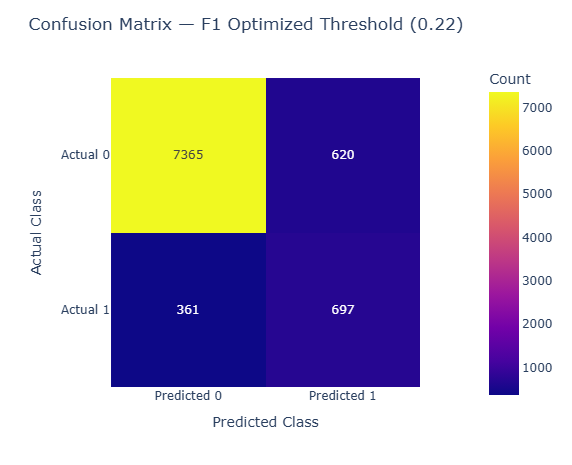

In [30]:
fig = px.imshow(
    cm_f1,
    text_auto=True,
    title=(
        f"Confusion Matrix — "
        f"F1 Optimized Threshold "
        f"({best_f1_threshold:.2f})"
    ),
    labels={
        "x": "Predicted Class",
        "y": "Actual Class",
        "color": "Count"
    },
    x=["Predicted 0", "Predicted 1"],
    y=["Actual 0", "Actual 1"]
)

fig.update_layout(
    width=600,
    height=450,
    margin=dict(
        l=60,
        r=30,
        t=60,
        b=60
    )
)

fig.show()

In [31]:
confusion_comparison = pd.DataFrame({
    "Metric": [
        "True Negatives",
        "False Positives",
        "False Negatives",
        "True Positives"
    ],
    "Threshold 0.50": [
        cm_default[0, 0],
        cm_default[0, 1],
        cm_default[1, 0],
        cm_default[1, 1]
    ],
    "F1 Optimized": [
        cm_f1[0, 0],
        cm_f1[0, 1],
        cm_f1[1, 0],
        cm_f1[1, 1]
    ]
})

display(confusion_comparison)

,Metric,Threshold 0.50,F1 Optimized
0,True Negatives,7790,7365
1,False Positives,195,620
2,False Negatives,689,361
3,True Positives,369,697


In [32]:
print("=" * 80)
print("CLASSIFICATION REPORT — F1 OPTIMIZED THRESHOLD")
print("=" * 80)

print(
    classification_report(
        y_test,
        test_prediction_f1,
        target_names=[
            "No Subscription",
            "Subscription"
        ],
        zero_division=0
    )
)

CLASSIFICATION REPORT — F1 OPTIMIZED THRESHOLD
                 precision    recall  f1-score   support

No Subscription       0.95      0.92      0.94      7985
   Subscription       0.53      0.66      0.59      1058

       accuracy                           0.89      9043
      macro avg       0.74      0.79      0.76      9043
   weighted avg       0.90      0.89      0.90      9043



In [33]:
threshold_results_path = (
    "../results/metrics/"
    "threshold_optimization_results.csv"
)

threshold_results_df.to_csv(
    threshold_results_path,
    index=False
)

print(
    "Threshold results saved:",
    threshold_results_path
)

Threshold results saved: ../results/metrics/threshold_optimization_results.csv


In [37]:
# ============================================================
# CELL 27 — COMPARE TEST THRESHOLDS
# ============================================================

test_threshold_comparison = pd.concat(
    [
        default_test_metrics_df.assign(
            Threshold_Type="Default 0.50"
        ),
        f1_optimized_test_metrics_df.assign(
            Threshold_Type="F1 Optimized"
        )
    ],
    ignore_index=True
)

columns_order = [
    "Threshold_Type",
    "Threshold",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "Balanced_Accuracy",
    "PR_AUC",
    "ROC_AUC"
]

test_threshold_comparison = (
    test_threshold_comparison[
        columns_order
    ]
)

print("=" * 80)
print("TEST SET — DEFAULT VS F1-OPTIMIZED THRESHOLD")
print("=" * 80)

display(
    test_threshold_comparison.round(4)
)

TEST SET — DEFAULT VS F1-OPTIMIZED THRESHOLD


,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,ROC_AUC
0,Default 0.50,0.50,0.9022,0.6543,0.3488,0.4550,0.6622,0.5591,0.9109
1,F1 Optimized,0.22,0.8915,0.5292,0.6588,0.5869,0.7906,0.5591,0.9109


In [39]:
# ============================================================
# CELL 33 — SAVE TEST THRESHOLD COMPARISON
# ============================================================

test_comparison_path = (
    "../results/metrics/"
    "threshold_test_comparison.csv"
)

test_threshold_comparison.to_csv(
    test_comparison_path,
    index=False
)

print(
    "Test comparison saved successfully:"
)

print(test_comparison_path)

print("\nSaved comparison:")
display(
    test_threshold_comparison.round(4)
)

Test comparison saved successfully:
../results/metrics/threshold_test_comparison.csv

Saved comparison:


,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,ROC_AUC
0,Default 0.50,0.50,0.9022,0.6543,0.3488,0.4550,0.6622,0.5591,0.9109
1,F1 Optimized,0.22,0.8915,0.5292,0.6588,0.5869,0.7906,0.5591,0.9109


In [40]:
# ============================================================
# CELL 33 — SAVE TEST THRESHOLD COMPARISON
# ============================================================

test_comparison_path = (
    "../results/metrics/"
    "threshold_test_comparison.csv"
)

test_threshold_comparison.to_csv(
    test_comparison_path,
    index=False
)

print(
    "Test comparison saved successfully:"
)

print(test_comparison_path)

print("\nSaved comparison:")
display(
    test_threshold_comparison.round(4)
)

Test comparison saved successfully:
../results/metrics/threshold_test_comparison.csv

Saved comparison:


,Threshold_Type,Threshold,Accuracy,Precision,Recall,F1,Balanced_Accuracy,PR_AUC,ROC_AUC
0,Default 0.50,0.50,0.9022,0.6543,0.3488,0.4550,0.6622,0.5591,0.9109
1,F1 Optimized,0.22,0.8915,0.5292,0.6588,0.5869,0.7906,0.5591,0.9109


In [41]:
# ============================================================
# CELL 35 — STAGE 8 VALIDATION
# ============================================================

print("=" * 80)
print("STAGE 8 VALIDATION")
print("=" * 80)

# ------------------------------------------------------------
# Check threshold range
# ------------------------------------------------------------

assert (
    threshold_results_df["Threshold"].min()
    >= 0.10
)

assert (
    threshold_results_df["Threshold"].max()
    <= 0.90
)

print("\n✓ Threshold search range is valid.")


# ------------------------------------------------------------
# Check probability values
# ------------------------------------------------------------

assert np.isfinite(
    oof_probabilities
).all()

assert (
    oof_probabilities.min() >= 0
)

assert (
    oof_probabilities.max() <= 1
)

assert np.isfinite(
    test_probabilities
).all()

print("✓ Probability values are valid.")


# ------------------------------------------------------------
# Check selected threshold
# ------------------------------------------------------------

assert (
    0.10 <= best_f1_threshold <= 0.90
)

print(
    f"✓ Selected F1 threshold: "
    f"{best_f1_threshold:.2f}"
)


# ------------------------------------------------------------
# Check test prediction dimensions
# ------------------------------------------------------------

assert len(test_prediction_default) == len(y_test)
assert len(test_prediction_f1) == len(y_test)

print("✓ Test prediction dimensions are valid.")


# ------------------------------------------------------------
# Check saved files
# ------------------------------------------------------------

assert os.path.exists(
    "../results/metrics/"
    "threshold_optimization_results.csv"
)

assert os.path.exists(
    "../results/metrics/"
    "threshold_test_comparison.csv"
)

assert os.path.exists(
    "../results/metrics/"
    "selected_threshold.csv"
)

print("✓ Required Stage 8 output files exist.")


# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("STAGE 8 VALIDATION COMPLETED SUCCESSFULLY")
print("=" * 80)

STAGE 8 VALIDATION

✓ Threshold search range is valid.
✓ Probability values are valid.
✓ Selected F1 threshold: 0.22
✓ Test prediction dimensions are valid.
✓ Required Stage 8 output files exist.

STAGE 8 VALIDATION COMPLETED SUCCESSFULLY
